# TFX Pipeline: MovieLens 100k Recommendation System

## Production-Style Pipeline for "Like" Prediction

**Objective**: Build an end-to-end TFX pipeline to predict whether a user likes a movie (rating â‰¥ 4) using the MovieLens 100k dataset.

**Key Features**:
- âœ… **Two-tower dot product architecture** with embedding-based features
- âœ… **Time-based split** (70/15/15) for realistic production scenario
- âœ… **Hybrid approach**: Collaborative filtering + content-based features
- âœ… **ROC-AUC evaluation** with threshold-based metrics
- âœ… **Kubeflow Pipelines** for scalable orchestration

**Architecture**:
- **User Tower**: user_id + age + gender + occupation â†’ embeddings â†’ Dense(64) â†’ user_vector
- **Movie Tower**: movie_id + genres â†’ embeddings â†’ Dense(64) â†’ movie_vector
- **Interaction**: dot_product(user_vector, movie_vector) â†’ sigmoid â†’ prediction

## 1. Setup and Imports

Install required dependencies and import libraries for TFX pipeline development.

In [1]:
# Install TFX and dependencies (uncomment to install)
# !pip install tfx>=1.13 tensorflow>=2.12 pandas scikit-learn matplotlib seaborn kfp>=1.8

import os
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_transform as tft
import tensorflow_model_analysis as tfma
from datetime import datetime
from typing import List, Dict, Tuple

# TFX imports
import tfx
from tfx.components import (
    CsvExampleGen,
    StatisticsGen,
    SchemaGen,
    ExampleValidator,
    Transform,
    Trainer,
    Evaluator,
    Pusher
)
from tfx.proto import example_gen_pb2, trainer_pb2, pusher_pb2
from tfx.orchestration import metadata, pipeline
from tfx.orchestration.local.local_dag_runner import LocalDagRunner
from tfx.dsl.components.common import resolver
from tfx.dsl.experimental import latest_blessed_model_resolver
from tfx.types import Channel
from tfx.types.standard_artifacts import Model, ModelBlessing

# Evaluation imports
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print(f"TFX version: {tfx.__version__}")

c:\Users\jings\_ML projects\TFX recommender\venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TensorFlow version: 2.13.0
TFX version: 1.14.0


## 2. Load Data and Data Exploration

Load and explore the MovieLens 100k dataset to understand its structure.

In [3]:
# Define paths
DATA_DIR = './ml-100k'

# Load datasets
ratings = pd.read_csv(
    os.path.join(DATA_DIR, 'u.data'),
    sep='\t',
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    encoding='latin-1'
)

users = pd.read_csv(
    os.path.join(DATA_DIR, 'u.user'),
    sep='|',
    names=['user_id', 'age', 'gender', 'occupation', 'zip_code'],
    encoding='latin-1'
)

# Load movie data with 19 genre columns
genre_cols = ['unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

movies = pd.read_csv(
    os.path.join(DATA_DIR, 'u.item'),
    sep='|',
    names=['movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url'] + genre_cols,
    encoding='latin-1'
)

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Ratings: {len(ratings):,} interactions")
print(f"Users: {len(users):,} users")
print(f"Movies: {len(movies):,} movies")
print(f"\nRatings per user: {ratings.groupby('user_id').size().describe()}")
print(f"\nRating distribution:\n{ratings['rating'].value_counts().sort_index()}")
print(f"\nTimestamp range: {pd.to_datetime(ratings['timestamp'], unit='s').min()} to {pd.to_datetime(ratings['timestamp'], unit='s').max()}")

DATASET OVERVIEW
Ratings: 100,000 interactions
Users: 943 users
Movies: 1,682 movies

Ratings per user: count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64

Rating distribution:
1     6110
2    11370
3    27145
4    34174
5    21201
Name: rating, dtype: int64

Timestamp range: 1997-09-20 03:05:10 to 1998-04-22 23:10:38


In [5]:
# Display sample data
print("\n" + "=" * 80)
print("SAMPLE DATA")
print("=" * 80)
print("\nRatings (first 5 rows):")
print(ratings.head())
print("\nUsers (first 5 rows):")
print(users.head())
print("\nMovies (first 3 rows with genres):")
print(movies[['movie_id', 'title'] + genre_cols[:5]].head(3))


SAMPLE DATA

Ratings (first 5 rows):
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596

Users (first 5 rows):
   user_id  age gender  occupation zip_code
0        1   24      M  technician    85711
1        2   53      F       other    94043
2        3   23      M      writer    32067
3        4   24      M  technician    43537
4        5   33      F       other    15213

Movies (first 3 rows with genres):
   movie_id              title  unknown  Action  Adventure  Animation  \
0         1   Toy Story (1995)        0       0          0          1   
1         2   GoldenEye (1995)        0       1          1          0   
2         3  Four Rooms (1995)        0       0          0          0   

   Children  
0         1  
1         0  
2         0  


## 3. Data Preparation with Time-Based Split

Prepare the data for TFX pipeline:
1. Join ratings with user and movie features
2. Create binary labels (rating â‰¥ 4 = like)
3. **Time-based split**: 80% train / 10% validation / 10% test (chronological)

In [4]:
# Join all data sources
merged_data = ratings.merge(users, on='user_id', how='left')
merged_data = merged_data.merge(movies, on='movie_id', how='left')

# Create binary label with neutral ratings removed:
#   positive = rating >= 4
#   negative = rating <= 2
#   drop     = rating == 3
merged_data = merged_data[merged_data['rating'] != 3].copy()
merged_data['label'] = (merged_data['rating'] >= 4).astype(int)

# Extract active genres for each movie (convert to list of genre names)
def get_active_genres(row):
    active = [genre for genre in genre_cols if row[genre] == 1]
    return '|'.join(active) if active else 'unknown'

merged_data['genres'] = merged_data.apply(get_active_genres, axis=1)

# Select features for the model
feature_cols = ['user_id', 'movie_id', 'age', 'gender', 'occupation', 'genres', 'timestamp', 'label']
data = merged_data[feature_cols].copy()

# Check unique counts for key categorical/profile features
unique_cols = ['user_id', 'movie_id', 'age', 'gender', 'occupation', 'genres']
print("=" * 80)
print("UNIQUE VALUE COUNTS")
print("=" * 80)
for col in unique_cols:
    print(f"{col:<12}: {data[col].nunique():,}")

# check for data types
print("\n" + "=" * 80)
print("DATA TYPE CHECK")
print("=" * 80)
print(data.dtypes)

# Check for missing values
print("=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)
print(f"Total records: {len(data):,}")
print(f"Missing values:\n{data.isnull().sum()}")
print(f"\nLabel distribution:\n{data['label'].value_counts()}")
print(f"Label proportion: {data['label'].mean():.1%} likes")

UNIQUE VALUE COUNTS
user_id     : 943
movie_id    : 1,682
age         : 61
gender      : 2
occupation  : 21
genres      : 216

DATA TYPE CHECK
user_id        int64
movie_id       int64
age            int64
gender        object
occupation    object
genres        object
timestamp      int64
label          int32
dtype: object
DATA QUALITY CHECK
Total records: 100,000
Missing values:
user_id       0
movie_id      0
age           0
gender        0
occupation    0
genres        0
timestamp     0
label         0
dtype: int64

Label distribution:
1    55375
0    44625
Name: label, dtype: int64
Label proportion: 55.4% likes


In [ ]:
# TIME-BASED SPLIT: Sort by timestamp and split chronologically
# This simulates production scenario: train on past, predict future

data_sorted = data.sort_values('timestamp').reset_index(drop=True)

n_total = len(data_sorted)
n_train = int(n_total * 0.80)
n_val = int(n_total * 0.10)
n_test = n_total - n_train - n_val

train_data = data_sorted.iloc[:n_train]
val_data = data_sorted.iloc[n_train:n_train+n_val]
test_data = data_sorted.iloc[n_train+n_val:]

print("\n" + "=" * 80)
print("TIME-BASED SPLIT (80/10/10)")
print("=" * 80)
print(f"Train set: {len(train_data):,} samples ({len(train_data)/n_total:.1%})")
print(f"  Timestamp range: {pd.to_datetime(train_data['timestamp'].min(), unit='s')} to {pd.to_datetime(train_data['timestamp'].max(), unit='s')}")
print(f"  Label proportion: {train_data['label'].mean():.1%} likes")

print(f"\nValidation set: {len(val_data):,} samples ({len(val_data)/n_total:.1%})")
print(f"  Timestamp range: {pd.to_datetime(val_data['timestamp'].min(), unit='s')} to {pd.to_datetime(val_data['timestamp'].max(), unit='s')}")
print(f"  Label proportion: {val_data['label'].mean():.1%} likes")

print(f"\nTest set: {len(test_data):,} samples ({len(test_data)/n_total:.1%})")
print(f"  Timestamp range: {pd.to_datetime(test_data['timestamp'].min(), unit='s')} to {pd.to_datetime(test_data['timestamp'].max(), unit='s')}")
print(f"  Label proportion: {test_data['label'].mean():.1%} likes")

# Verify no temporal leakage
# Use <= because tied timestamps at split boundaries are not true leakage
# (records are in sorted order by index; equal boundary timestamps are expected)
assert train_data['timestamp'].max() <= val_data['timestamp'].min(), "Temporal leakage detected!"
assert val_data['timestamp'].max() <= test_data['timestamp'].min(), "Temporal leakage detected!"
print("\n Temporal integrity verified: train timestamps <= validation timestamps <= test timestamps")


TIME-BASED SPLIT (80/10/10)
Train set: 80,000 samples (80.0%)
  Timestamp range: 1997-09-20 03:05:10 to 1998-03-07 02:21:09
  Label proportion: 55.1% likes

Validation set: 10,000 samples (10.0%)
  Timestamp range: 1998-03-07 02:21:09 to 1998-03-31 22:11:07
  Label proportion: 56.7% likes

Test set: 10,000 samples (10.0%)
  Timestamp range: 1998-03-31 22:11:49 to 1998-04-22 23:10:38
  Label proportion: 56.3% likes

âœ… Temporal integrity verified: train timestamps <= validation timestamps <= test timestamps


In [6]:
# Save splits to CSV for TFX ingestion
os.makedirs('./data', exist_ok=True)

train_data.to_csv('./data/train.csv', index=False)
val_data.to_csv('./data/val.csv', index=False)
test_data.to_csv('./data/test.csv', index=False)

print("\n" + "=" * 80)
print("DATA SAVED")
print("=" * 80)
print(" ./data/train.csv")
print(" ./data/val.csv")
print(" ./data/test.csv")


DATA SAVED
 ./data/train.csv
 ./data/val.csv
 ./data/test.csv


## 4. TFX Transform Component - Preprocessing Function

Define the preprocessing logic for feature engineering:
- Create vocabularies for user_id, movie_id, occupation
- Bucketize age into 6 bins
- Encode gender
- Process genres (multi-label)

In [ ]:
# Save preprocessing function to a separate module
TRANSFORM_MODULE_FILE = 'transform_module.py'

transform_code = '''
import tensorflow as tf
import tensorflow_transform as tft

# Feature names
USER_ID_KEY = 'user_id'
MOVIE_ID_KEY = 'movie_id'
AGE_KEY = 'age'
GENDER_KEY = 'gender'
OCCUPATION_KEY = 'occupation'
GENRES_KEY = 'genres'
LABEL_KEY = 'label'

# Embedding dimensions
USER_EMBEDDING_DIM = 32
MOVIE_EMBEDDING_DIM = 32
AGE_EMBEDDING_DIM = 12
GENDER_EMBEDDING_DIM = 6
OCCUPATION_EMBEDDING_DIM = 12
GENRE_EMBEDDING_DIM = 12

def preprocessing_fn(inputs):
    """
    TFX Transform preprocessing function.

    Transforms raw features into model-ready features:
    - Creates vocabularies for categorical features
    - Bucketizes age
    - Processes genres
    """
    outputs = {}

    # Reserve one OOV bucket so unknown tokens map to valid ids (never -1).
    outputs[USER_ID_KEY] = tft.compute_and_apply_vocabulary(
        inputs[USER_ID_KEY],
        vocab_filename=USER_ID_KEY,
        num_oov_buckets=1
    )

    outputs[MOVIE_ID_KEY] = tft.compute_and_apply_vocabulary(
        inputs[MOVIE_ID_KEY],
        vocab_filename=MOVIE_ID_KEY,
        num_oov_buckets=1
    )

    # Age: fixed buckets. apply_buckets expects rank-2 boundaries.
    outputs[AGE_KEY] = tft.apply_buckets(
        inputs[AGE_KEY],
        bucket_boundaries=[[18, 25, 35, 45, 55]]
    )

    outputs[GENDER_KEY] = tft.compute_and_apply_vocabulary(
        inputs[GENDER_KEY],
        vocab_filename=GENDER_KEY,
        num_oov_buckets=1
    )

    outputs[OCCUPATION_KEY] = tft.compute_and_apply_vocabulary(
        inputs[OCCUPATION_KEY],
        vocab_filename=OCCUPATION_KEY,
        num_oov_buckets=1
    )

    # Genres: split pipe-delimited strings and vocab-encode tokens
    genre_values = tf.reshape(inputs[GENRES_KEY], [-1])
    genre_tokens = tf.strings.split(genre_values, sep='|').to_sparse()
    outputs[GENRES_KEY] = tft.compute_and_apply_vocabulary(
        genre_tokens,
        vocab_filename=GENRES_KEY,
        num_oov_buckets=1
    )

    # Label: Binary (0/1)
    outputs[LABEL_KEY] = inputs[LABEL_KEY]

    return outputs
'''

with open(TRANSFORM_MODULE_FILE, 'w', encoding='utf-8') as f:
    f.write(transform_code)

print(f"Transform module saved to {TRANSFORM_MODULE_FILE}")

âœ… Transform module saved to transform_module.py


## 5. Two-Tower Dot Product Model

Define the two-tower architecture:
- **User Tower**: user_id + age + gender + occupation embeddings â†’ Dense(64) â†’ user_vector
- **Movie Tower**: movie_id + genre embeddings (averaged) â†’ Dense(64) â†’ movie_vector
- **Interaction**: dot_product(user_vector, movie_vector) â†’ sigmoid â†’ prediction

In [ ]:
# Trainer module is maintained in trainer_module.py.
# This cell intentionally does not rewrite it, so local edits such as
# USE_USER_AWARE_ATTENTION and UserAwareAttention are preserved.
from pathlib import Path

TRAINER_MODULE_FILE = 'trainer_module.py'
trainer_path = Path(TRAINER_MODULE_FILE)
if not trainer_path.exists():
    raise FileNotFoundError(f'{TRAINER_MODULE_FILE} not found')

print(f'Trainer module ready: {trainer_path.resolve()}')


Trainer module saved to trainer_module.py


## 6. TFX Pipeline Definition

Define the complete TFX pipeline with all components:
1. **CsvExampleGen**: Ingest CSV data
2. **StatisticsGen**: Generate statistics
3. **SchemaGen**: Infer schema
4. **ExampleValidator**: Validate data quality
5. **Transform**: Feature preprocessing
6. **Trainer**: Train the model
7. **Evaluator**: Evaluate with ROC-AUC and threshold metrics
8. **Pusher**: Deploy the model

In [117]:
# Keep this cell runnable even if the setup/import cell was not executed in this kernel.
import tensorflow_model_analysis as tfma
from tfx.components import (
    CsvExampleGen,
    StatisticsGen,
    SchemaGen,
    ExampleValidator,
    Transform,
    Trainer,
    Evaluator,
    Pusher,
)
from tfx.proto import example_gen_pb2, trainer_pb2, pusher_pb2
from tfx.orchestration import metadata, pipeline
from tfx.dsl.components.common import resolver
from tfx.dsl.experimental import latest_blessed_model_resolver
from tfx.types import Channel
from tfx.types.standard_artifacts import Model, ModelBlessing


def create_pipeline(
    pipeline_name: str,
    pipeline_root: str,
    data_root: str,
    transform_module_path: str,
    trainer_module_path: str,
    serving_model_dir: str,
    metadata_path: str,
    use_user_aware_attention: bool = True
):
    """
    Create TFX pipeline for MovieLens recommendation.
    
    Args:
        pipeline_name: Name of the pipeline
        pipeline_root: Root directory for pipeline outputs
        data_root: Directory containing train/val/test CSV files
        transform_module_path: Path to transform module
        trainer_module_path: Path to trainer module
        serving_model_dir: Directory for serving models
        metadata_path: Path to metadata database
        use_user_aware_attention: Whether to use user-conditioned genre attention instead of average pooling
    
    Returns:
        TFX Pipeline object
    """
    
    # 1. CsvExampleGen: Ingest pre-split CSV files
    # input_config maps each file to its named split, preserving the
    # manual time-based split. Without this, CsvExampleGen would ignore
    # the file names and randomly re-split all records (default: 2/3 train, 1/3 eval).
    # Downstream Trainer looks for splits named 'train' and 'eval'.
    example_gen = CsvExampleGen(
        input_base=data_root,
        input_config=example_gen_pb2.Input(splits=[
            example_gen_pb2.Input.Split(name='train', pattern='train.csv'),
            example_gen_pb2.Input.Split(name='eval',  pattern='val.csv'),
            example_gen_pb2.Input.Split(name='test',  pattern='test.csv'),
        ])
    )
    
    # 2. StatisticsGen: Generate statistics for data analysis
    statistics_gen = StatisticsGen(
        examples=example_gen.outputs['examples']
    )
    
    # 3. SchemaGen: Infer schema from statistics
    schema_gen = SchemaGen(
        statistics=statistics_gen.outputs['statistics']
    )
    
    # 4. ExampleValidator: Validate data quality
    example_validator = ExampleValidator(
        statistics=statistics_gen.outputs['statistics'],
        schema=schema_gen.outputs['schema']
    )
    
    # 5. Transform: Apply feature preprocessing
    transform = Transform(
        examples=example_gen.outputs['examples'],
        schema=schema_gen.outputs['schema'],
        module_file=transform_module_path
    )
    
    # 6. Trainer: Train the two-tower model
    trainer = Trainer(
        module_file=trainer_module_path,
        examples=transform.outputs['transformed_examples'],
        transform_graph=transform.outputs['transform_graph'],
        schema=schema_gen.outputs['schema'],
        train_args=trainer_pb2.TrainArgs(num_steps=2000),
        eval_args=trainer_pb2.EvalArgs(num_steps=200),
        custom_config={'use_user_aware_attention': use_user_aware_attention}
    )
    
    # 7. Resolver: Find the latest blessed model to use as TFMA baseline.
    # On the first run there is no blessed model yet, so Evaluator uses only
    # value thresholds. Later runs compare the candidate against this baseline.
    model_resolver = resolver.Resolver(
        strategy_class=latest_blessed_model_resolver.LatestBlessedModelResolver,
        model=Channel(type=Model),
        model_blessing=Channel(type=ModelBlessing)
    ).with_id('latest_blessed_model_resolver')
    
    # 8. Evaluator: Evaluate model with ROC-AUC and threshold metrics
    # Use transformed_examples so TFMA feature dtypes match the trained model inputs.

    eval_config = tfma.EvalConfig(
        model_specs=[tfma.ModelSpec(label_key='label')],
        slicing_specs=[
            tfma.SlicingSpec(),  # Overall metrics
            # # User slices
            # tfma.SlicingSpec(feature_keys=['gender']),
            # tfma.SlicingSpec(feature_keys=['age']),
            # tfma.SlicingSpec(feature_keys=['occupation']),
            # # Item slices
            # tfma.SlicingSpec(feature_keys=['genres']),
        ],
        metrics_specs=[
            tfma.MetricsSpec(
                metrics=[
                    tfma.MetricConfig(
                        class_name='AUC',
                        threshold=tfma.MetricThreshold(
                            value_threshold=tfma.GenericValueThreshold(
                                lower_bound={'value': 0.6}
                            ),
                            change_threshold=tfma.GenericChangeThreshold(
                                direction=tfma.MetricDirection.HIGHER_IS_BETTER,
                                absolute={'value': 0.0}
                            )
                        )
                    ),
                    tfma.MetricConfig(class_name='Precision'),
                    tfma.MetricConfig(class_name='Recall'),
                    tfma.MetricConfig(class_name='BinaryAccuracy'),
                    tfma.MetricConfig(class_name='ConfusionMatrixPlot'),
                    tfma.MetricConfig(class_name='CalibrationPlot'),
                    tfma.MetricConfig(
                        class_name='Precision',
                        threshold=tfma.MetricThreshold(
                            value_threshold=tfma.GenericValueThreshold(
                                lower_bound={'value': 0.6}
                            )
                        )
                    )
                ]
            )
        ]
    )
    
    evaluator = Evaluator(
        examples=transform.outputs['transformed_examples'],
        model=trainer.outputs['model'],
        baseline_model=model_resolver.outputs['model'],
        eval_config=eval_config,
        example_splits=['eval']
    )
    
    # 9. Pusher: Deploy model if evaluation passes
    pusher = Pusher(
        model=trainer.outputs['model'],
        model_blessing=evaluator.outputs['blessing'],
        push_destination=pusher_pb2.PushDestination(
            filesystem=pusher_pb2.PushDestination.Filesystem(
                base_directory=serving_model_dir
            )
        )
    )
    
    # Create pipeline
    components = [
        example_gen,
        statistics_gen,
        schema_gen,
        example_validator,
        transform,
        trainer,
        model_resolver,
        evaluator,
        pusher
    ]
    
    return pipeline.Pipeline(
        pipeline_name=pipeline_name,
        pipeline_root=pipeline_root,
        components=components,
        metadata_connection_config=metadata.sqlite_metadata_connection_config(
            metadata_path
        ),
        enable_cache=True
    )

print(" Pipeline creation function defined")

 Pipeline creation function defined


## 7. Run Pipeline Locally

Execute the pipeline using LocalDagRunner for local development and testing.

In [118]:
# Keep this cell runnable even if the setup/import cell was not executed in this kernel.
import os
from tfx.orchestration.local.local_dag_runner import LocalDagRunner

# define paths
PIPELINE_ROOT = './tfx_pipeline_output'
METADATA_PATH = os.path.join(PIPELINE_ROOT, 'metadata.sqlite')
SERVING_MODEL_DIR = os.path.join(PIPELINE_ROOT, 'serving_model')
TRANSFORM_MODULE_FILE = globals().get('TRANSFORM_MODULE_FILE', 'transform_module.py')
TRAINER_MODULE_FILE = globals().get('TRAINER_MODULE_FILE', 'trainer_module.py')
USE_USER_AWARE_ATTENTION = globals().get('USE_USER_AWARE_ATTENTION', True)

# Create the pipeline
tfx_pipeline = create_pipeline(
    pipeline_name='movielens_recommender_pipeline',
    pipeline_root=PIPELINE_ROOT,
    data_root='./data',
    transform_module_path=os.path.abspath(TRANSFORM_MODULE_FILE),
    trainer_module_path=os.path.abspath(TRAINER_MODULE_FILE),
    serving_model_dir=SERVING_MODEL_DIR,
    metadata_path=METADATA_PATH,
    use_user_aware_attention=USE_USER_AWARE_ATTENTION
)

# Windows workaround 1: MLMD filter-query path can fail on Windows in some versions.
# Patch TFX execution lookup to intersect context executions in Python (no SQL filter).
def _patch_tfx_mlmd_windows_filtering_bug():
    import platform
    if platform.system().lower() != 'windows':
        return

    from tfx.orchestration.portable.mlmd import execution_lib as _execution_lib

    # Idempotent patch.
    if getattr(_execution_lib, '_WINDOWS_FILTER_PATCHED', False):
        return

    def _get_executions_associated_with_all_contexts_no_filter(metadata_handler, contexts):
        context_list = list(contexts)
        if not context_list:
            return []

        common_ids = None
        for context in context_list:
            executions = metadata_handler.store.get_executions_by_context(context.id)
            ids = {e.id for e in executions}
            common_ids = ids if common_ids is None else (common_ids & ids)
            if not common_ids:
                return []

        executions_by_id = {}
        for context in context_list:
            for execution in metadata_handler.store.get_executions_by_context(context.id):
                if execution.id in common_ids:
                    executions_by_id[execution.id] = execution

        return list(executions_by_id.values())

    _execution_lib.get_executions_associated_with_all_contexts = (
        _get_executions_associated_with_all_contexts_no_filter
    )
    _execution_lib._WINDOWS_FILTER_PATCHED = True


# Windows workaround 2: sanitize run-id suffix used in stateful working directory.
# Some TFX versions use ISO timestamps with ':' which is invalid in Windows paths.
def _patch_tfx_windows_stateful_dir_bug():
    import platform
    import re

    if platform.system().lower() != 'windows':
        return

    from tfx.orchestration.portable import outputs_utils as _outputs_utils

    if getattr(_outputs_utils, '_WINDOWS_STATEFUL_DIR_PATCHED', False):
        return

    _orig = _outputs_utils.get_stateful_working_directory

    def _safe_get_stateful_working_directory(node_dir, execution_mode, pipeline_run_id='', execution_id=None):
        safe_run_id = re.sub(r'[<>:"/\\|?*]', '-', str(pipeline_run_id))
        return _orig(
            node_dir=node_dir,
            execution_mode=execution_mode,
            pipeline_run_id=safe_run_id,
            execution_id=execution_id,
        )

    _outputs_utils.get_stateful_working_directory = _safe_get_stateful_working_directory
    _outputs_utils._WINDOWS_STATEFUL_DIR_PATCHED = True


_patch_tfx_mlmd_windows_filtering_bug()
_patch_tfx_windows_stateful_dir_bug()

# Run the pipeline locally
print("=" * 80)
print("RUNNING TFX PIPELINE")
print("=" * 80)
print(f"Pipeline: {tfx_pipeline.pipeline_info.pipeline_name}")
print(f"Components: {len(tfx_pipeline.components)}")
print("\nThis may take several minutes...")
print("=" * 80)

# Uncomment to run the pipeline
LocalDagRunner().run(tfx_pipeline)

print("\nPipeline execution complete!")
print(f"\nArtifacts saved to: {PIPELINE_ROOT}")
print(f"Metadata database: {METADATA_PATH}")
print(f"Serving model: {SERVING_MODEL_DIR}")


RUNNING TFX PIPELINE
Pipeline: movielens_recommender_pipeline
Components: 9

This may take several minutes...



Pipeline execution complete!

Artifacts saved to: ./tfx_pipeline_output
Metadata database: ./tfx_pipeline_output\metadata.sqlite
Serving model: ./tfx_pipeline_output\serving_model


## 8. Evaluation with Threshold-Based Metrics

After pipeline execution, analyze model performance with:
- **ROC-AUC**: Threshold-independent ranking metric
- **Precision/Recall/F1** at multiple thresholds (0.3, 0.5, 0.7)
- **Confusion Matrix** at default threshold

TFMA EVALUATOR RESULTS
Evaluation dir: ./tfx_pipeline_output\Evaluator\evaluation\472
Blessing dir  : ./tfx_pipeline_output\Evaluator\blessing\472
Model blessing: NOT_BLESSED



Rendering TFMA slicing metrics (all slices)...

Available slice columns: none

Skipping 'gender' slice view: no slices found for this column.

Skipping 'occupation' slice view: no slices found for this column.

Rendering TFMA plot view when plot data is available...
Skipping TFMA plot view: this evaluation contains metrics but no plot payloads.
AUC is still available in the slicing metrics table above.

CURRENT VS BASELINE METRICS (overall slice)
Baseline values are inferred as current - delta when TFMA provides *_diff metrics.
Metric                                      Current     Baseline        Delta
-------------------------------------- ------------ ------------ ------------
auc                                        0.689660     0.693946    -0.004286
binary_accuracy                            0.650500     0.653000    -0.002500
precision                                  0.644209     0.651249    -0.007040
recall                                     0.857772     0.836271     0.0215

,epoch,loss,eval_loss
0,1,0.623329,0.638836
1,2,0.562925,0.639999
2,3,0.553042,0.641120
3,4,0.545268,0.642660
4,5,0.536700,0.642731


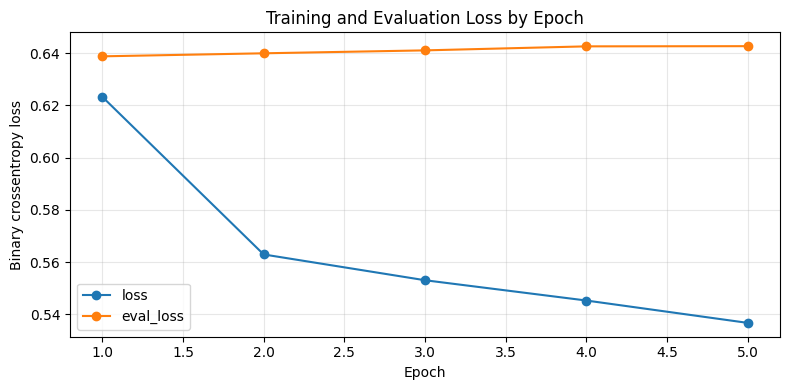

In [122]:
# TFMA-native evaluation viewer with baseline comparison
import os
import glob
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import tensorflow_model_analysis as tfma
from tensorflow_model_analysis.proto import validation_result_pb2


def _latest_subdir(parent: str) -> str:
    """Return the latest run directory, preferring numeric directory names."""
    subdirs = [
        d for d in glob.glob(os.path.join(parent, '*'))
        if os.path.isdir(d)
    ]
    if not subdirs:
        raise FileNotFoundError(f'No subdirectories found under: {parent}')

    numeric = []
    for d in subdirs:
        name = os.path.basename(d)
        if name.isdigit():
            numeric.append((int(name), d))

    if numeric:
        numeric.sort(key=lambda x: x[0])
        return numeric[-1][1]

    # Fallback for non-numeric run folder names.
    return sorted(subdirs)[-1]


def _flatten_metrics(node, prefix='') -> dict[str, float]:
    """Flatten nested TFMA metric dicts into name -> float values."""
    flat: dict[str, float] = {}
    if isinstance(node, dict):
        if 'doubleValue' in node:
            key = prefix.strip('/') if prefix else 'value'
            flat[key] = float(node['doubleValue'])
            return flat
        for k, v in node.items():
            child_prefix = f'{prefix}/{k}' if prefix else str(k)
            flat.update(_flatten_metrics(v, child_prefix))
        return flat
    if isinstance(node, (int, float)):
        key = prefix.strip('/') if prefix else 'value'
        flat[key] = float(node)
    return flat


def _overall_slice_metrics(eval_result):
    """Return the metrics dict for the overall slice, if present."""
    slicing_metrics = eval_result.slicing_metrics
    for slice_key, metrics_dict in slicing_metrics:
        if slice_key == () or slice_key == ((),):
            return metrics_dict
    if slicing_metrics:
        return slicing_metrics[0][1]
    return None


def _extract_slice_columns(slice_key) -> set[str]:
    """Extract slice column names from a TFMA slice key payload."""
    cols: set[str] = set()

    def _walk(node):
        if isinstance(node, tuple):
            if len(node) == 2 and isinstance(node[0], str):
                cols.add(node[0])
                return
            for item in node:
                _walk(item)
        elif isinstance(node, list):
            for item in node:
                _walk(item)
        elif isinstance(node, dict):
            for k, v in node.items():
                if isinstance(k, str):
                    cols.add(k)
                _walk(v)

    _walk(slice_key)
    return cols


def _available_slice_columns(eval_result) -> list[str]:
    """Return sorted list of available slice columns in eval_result."""
    columns: set[str] = set()
    for slice_key, _ in eval_result.slicing_metrics:
        columns.update(_extract_slice_columns(slice_key))
    return sorted(c for c in columns if c)


def _safe_render_slicing_metrics(eval_result, slicing_column: str, available_columns: set[str]) -> None:
    """Render slicing metrics only when the requested column exists."""
    if slicing_column in available_columns:
        print(f'\nRendering TFMA slicing metrics by {slicing_column}...')
        tfma.view.render_slicing_metrics(eval_result, slicing_column=slicing_column)
    else:
        print(f"\nSkipping '{slicing_column}' slice view: no slices found for this column.")


def _has_renderable_plot_data(eval_result) -> bool:
    """Return True when TFMA produced non-empty plot payloads."""
    for _, plot_payload in getattr(eval_result, 'plots', []) or []:
        if plot_payload:
            return True
    return False


def _safe_render_auc_plot(eval_result) -> None:
    """Render TFMA plots only when the Evaluator produced plot payloads."""
    print('\nRendering TFMA plot view when plot data is available...')
    if not _has_renderable_plot_data(eval_result):
        print('Skipping TFMA plot view: this evaluation contains metrics but no plot payloads.')
        print('AUC is still available in the slicing metrics table above.')
        return

    try:
        tfma.view.render_plot(eval_result)
    except Exception as exc:
        print(f'Could not render TFMA plot in this environment: {exc}')


def _summary_value_to_float(summary_value) -> float | None:
    """Extract a scalar float from a TensorBoard summary value."""
    if summary_value.HasField('tensor'):
        value = tf.make_ndarray(summary_value.tensor)
        if value.size:
            return float(value.reshape(-1)[0])
        return None
    return float(summary_value.simple_value)


def _read_tensorboard_scalars(log_dir: str, tag: str) -> list[tuple[int, float]]:
    """Read scalar values for one TensorBoard tag from a log directory."""
    event_files = sorted(
        glob.glob(os.path.join(log_dir, 'events.out.tfevents.*')),
        key=os.path.getmtime,
    )
    values_by_step = {}
    for event_file in event_files:
        try:
            iterator = tf.compat.v1.train.summary_iterator(event_file)
            for event in iterator:
                for value in event.summary.value:
                    if value.tag != tag:
                        continue
                    scalar = _summary_value_to_float(value)
                    if scalar is not None:
                        values_by_step[int(event.step)] = scalar
        except Exception as exc:
            print(f'Could not read TensorBoard event file {event_file}: {exc}')

    return sorted(values_by_step.items())


def _loss_rows(train_loss: list[tuple[int, float]], eval_loss: list[tuple[int, float]]) -> pd.DataFrame:
    """Build an epoch-level train/eval loss table from TensorBoard scalars."""
    train_by_epoch = {step + 1: value for step, value in train_loss}
    eval_by_epoch = {step + 1: value for step, value in eval_loss}
    epochs = sorted(set(train_by_epoch) | set(eval_by_epoch))
    return pd.DataFrame(
        {
            'epoch': epochs,
            'loss': [train_by_epoch.get(epoch) for epoch in epochs],
            'eval_loss': [eval_by_epoch.get(epoch) for epoch in epochs],
        }
    )


def _plot_training_loss(trainer_root: str) -> None:
    """Plot train loss and eval loss from the latest Trainer model_run logs."""
    model_run_root = os.path.join(trainer_root, 'model_run')
    if not os.path.isdir(model_run_root):
        print(f'\nTrainer model_run logs not found at: {model_run_root}')
        return

    model_run_dir = _latest_subdir(model_run_root)
    train_log_dir = os.path.join(model_run_dir, 'train')
    validation_log_dir = os.path.join(model_run_dir, 'validation')

    train_loss = _read_tensorboard_scalars(train_log_dir, 'epoch_loss')
    eval_loss = _read_tensorboard_scalars(validation_log_dir, 'epoch_loss')

    print('\n' + '=' * 80)
    print('TRAINING HISTORY')
    print('=' * 80)
    print(f'Trainer model_run dir: {model_run_dir}')

    if not train_loss and not eval_loss:
        print('No epoch_loss TensorBoard scalars found for train or validation logs.')
        return

    loss_df = _loss_rows(train_loss, eval_loss)
    display(loss_df)

    ax = loss_df.plot(
        x='epoch',
        y=['loss', 'eval_loss'],
        marker='o',
        figsize=(8, 4),
        title='Training and Evaluation Loss by Epoch',
    )
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Binary crossentropy loss')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def _slice_key_to_text(slice_key) -> str:
    """Convert TFMA single_slice_keys proto to readable text across proto versions."""
    parts = []
    for item in slice_key.single_slice_keys:
        column = ''
        value = 'overall'
        for field_desc, field_val in item.ListFields():
            if field_desc.name == 'column':
                column = field_val
            else:
                if isinstance(field_val, bytes):
                    value = field_val.decode('utf-8', errors='replace')
                else:
                    value = str(field_val)
        parts.append(f'{column}={value}' if column else str(value))
    return ', '.join(parts) if parts else 'overall'


def _print_validation_failures(eval_dir: str) -> None:
    """Parse validations.tfrecord and print failing slices/metrics for latest run."""
    val_path = os.path.join(eval_dir, 'validations.tfrecord')
    print('\n' + '=' * 80)
    print('VALIDATION FAILURES (latest run)')
    print('=' * 80)

    if not os.path.exists(val_path):
        print(f'No validations.tfrecord found at: {val_path}')
        return

    vr = validation_result_pb2.ValidationResult()
    for raw in tf.data.TFRecordDataset(val_path).take(1):
        vr.ParseFromString(raw.numpy())

    print(f'validation_ok: {vr.validation_ok}')
    print(f'failed_slices: {len(vr.metric_validations_per_slice)}')

    if vr.validation_ok:
        print('No validation failures detected.')
        return

    failure_counter = Counter()
    rows = []
    for mvs in vr.metric_validations_per_slice:
        slice_text = _slice_key_to_text(mvs.slice_key)
        metric_names = []
        for fail in mvs.failures:
            metric = fail.metric_key.name
            if fail.metric_key.is_diff:
                metric = f'{metric}_diff'
            metric_names.append(metric)
            failure_counter[metric] += 1
        rows.append((slice_text, ', '.join(metric_names)))

    print(f"{'Slice':<55} {'Failed metrics':<30}")
    print(f"{'-' * 55} {'-' * 30}")
    for slice_text, metrics_text in rows:
        print(f"{slice_text[:55]:<55} {metrics_text[:30]:<30}")

    print('\nFailure counts by metric:')
    for metric, count in sorted(failure_counter.items()):
        print(f'  {metric}: {count}')


def _is_delta_metric(metric_name: str) -> bool:
    """Return True for TFMA baseline comparison delta/change metric names."""
    name = metric_name.lower()
    last_part = name.rsplit('/', 1)[-1]
    return last_part.endswith(('_diff', '_change', '_delta')) or last_part in {'diff', 'change', 'delta'}


def _delta_candidates(metric_name: str) -> list[str]:
    """Return likely TFMA delta metric names for a candidate metric name."""
    if '/' in metric_name:
        prefix, leaf = metric_name.rsplit('/', 1)
        return [
            f'{metric_name}_diff',
            f'{prefix}/{leaf}_diff',
            f'{metric_name}/diff',
            f'{metric_name}_change',
            f'{metric_name}_delta',
        ]
    return [
        f'{metric_name}_diff',
        f'{metric_name}/diff',
        f'{metric_name}_change',
        f'{metric_name}_delta',
    ]


def _find_delta(metric_name: str, flat_metrics: dict[str, float]) -> float | None:
    """Find the delta value corresponding to a candidate metric."""
    lower_to_key = {key.lower(): key for key in flat_metrics}
    for candidate in _delta_candidates(metric_name):
        key = lower_to_key.get(candidate.lower())
        if key is not None:
            return flat_metrics[key]
    return None


def _print_baseline_comparison(eval_result) -> None:
    """Print candidate and baseline metrics from overall-slice TFMA output."""
    overall_metrics = _overall_slice_metrics(eval_result)
    print('\n' + '=' * 80)
    print('CURRENT VS BASELINE METRICS (overall slice)')
    print('=' * 80)

    if overall_metrics is None:
        print('No overall-slice metrics available.')
        return

    flat = _flatten_metrics(overall_metrics)
    metric_items = {
        k: v for k, v in flat.items()
        if not _is_delta_metric(k)
    }

    if not metric_items:
        print('No candidate metric values found in metrics payload.')
        return

    print('Baseline values are inferred as current - delta when TFMA provides *_diff metrics.')
    print(f"{'Metric':<38} {'Current':>12} {'Baseline':>12} {'Delta':>12}")
    print(f"{'-' * 38} {'-' * 12} {'-' * 12} {'-' * 12}")
    for name, current_value in sorted(metric_items.items()):
        delta = _find_delta(name, flat)
        if delta is None:
            print(f"{name:<38} {current_value:>12.6f} {'n/a':>12} {'n/a':>12}")
        else:
            baseline_value = current_value - delta
            print(f"{name:<38} {current_value:>12.6f} {baseline_value:>12.6f} {delta:>12.6f}")


def view_tfma_results(evaluator_root: str, trainer_root: str | None = None) -> None:
    """Load TFMA eval result and render slicing views + baseline comparison."""
    eval_dir = _latest_subdir(os.path.join(evaluator_root, 'evaluation'))
    bless_dir = _latest_subdir(os.path.join(evaluator_root, 'blessing'))

    print('=' * 80)
    print('TFMA EVALUATOR RESULTS')
    print('=' * 80)
    print(f'Evaluation dir: {eval_dir}')
    print(f'Blessing dir  : {bless_dir}')

    if os.path.exists(os.path.join(bless_dir, 'BLESSED')):
        print('Model blessing: BLESSED')
    elif os.path.exists(os.path.join(bless_dir, 'NOT_BLESSED')):
        print('Model blessing: NOT_BLESSED')
    else:
        print('Model blessing: Unknown')

    eval_result = tfma.load_eval_result(output_path=eval_dir)

    print('\nRendering TFMA slicing metrics (all slices)...')
    tfma.view.render_slicing_metrics(eval_result)

    available_columns = set(_available_slice_columns(eval_result))
    print(f"\nAvailable slice columns: {sorted(available_columns) if available_columns else 'none'}")

    _safe_render_slicing_metrics(eval_result, 'gender', available_columns)
    _safe_render_slicing_metrics(eval_result, 'occupation', available_columns)

    _safe_render_auc_plot(eval_result)
    _print_baseline_comparison(eval_result)
    _print_validation_failures(eval_dir)

    if trainer_root is not None:
        _plot_training_loss(trainer_root)


_pipeline_root = globals().get('PIPELINE_ROOT', './tfx_pipeline_output')
EVALUATOR_ROOT = os.path.join(_pipeline_root, 'Evaluator')
TRAINER_ROOT = os.path.join(_pipeline_root, 'Trainer')

if not os.path.isdir(EVALUATOR_ROOT):
    print(f'Evaluator output not found at: {EVALUATOR_ROOT}')
    print('Run the TFX pipeline first (Cell 18), then re-run this cell.')
else:
    view_tfma_results(EVALUATOR_ROOT, TRAINER_ROOT)

## 9. Kubeflow Pipelines Deployment

Deploy the TFX pipeline to Kubeflow for production-scale orchestration on Kubernetes.

**Prerequisites**:
- Kubeflow Pipelines cluster running
- kubectl configured to access the cluster
- Pipeline artifacts stored in persistent storage (GCS/S3/PVC)

**Deployment Steps**:
1. Compile TFX pipeline to Kubeflow format
2. Upload to Kubeflow Pipelines UI or via SDK
3. Schedule pipeline runs
4. Monitor execution and artifacts

In [ ]:
# Kubeflow Pipelines deployment configuration
# NOTE: Requires kfp and its full dependency tree (including pyrsistent).
# If imports fail, install missing deps first:
#   pip install pyrsistent kfp>=1.8
try:
    import kfp
    from kfp.dsl import _container_op as _kfp_container_op
    # Defensive shim: some mixed/stale notebook states miss this flag.
    if not hasattr(kfp, 'COMPILING_FOR_V2'):
        kfp.COMPILING_FOR_V2 = False
    if not hasattr(_kfp_container_op.kfp, 'COMPILING_FOR_V2'):
        _kfp_container_op.kfp.COMPILING_FOR_V2 = False
    from tfx.orchestration.kubeflow import kubeflow_dag_runner
    from tfx.orchestration.kubeflow.kubeflow_dag_runner import KubeflowDagRunnerConfig
    _kubeflow_available = True
except (ImportError, ModuleNotFoundError, AttributeError) as _kfp_err:
    _kubeflow_available = False
    print(f' Kubeflow imports unavailable: {_kfp_err}')
    print('   Run:  pip install pyrsistent kfp>=1.8  then restart the kernel.')

# Configuration for Kubeflow deployment
KUBEFLOW_NAMESPACE = 'kubeflow'
KUBEFLOW_PIPELINE_NAME = 'movielens-recommender-pipeline'
KUBEFLOW_PIPELINE_FILE = f'{KUBEFLOW_PIPELINE_NAME}.yaml'

# GCS/S3 paths for production (replace placeholders with real buckets).
PIPELINE_ROOT_GCS = 'gs://your-bucket/tfx_pipeline'
DATA_ROOT_GCS = 'gs://your-bucket/data'


def _looks_like_placeholder_gcs(path: str) -> bool:
    return isinstance(path, str) and path.startswith('gs://') and 'your-bucket' in path


def _ensure_kfp_compile_flag() -> None:
    """Ensure COMPILING_FOR_V2 exists for both kfp and container-op module refs."""
    import kfp as _kfp
    from kfp.dsl import _container_op as _container_op

    if not hasattr(_kfp, 'COMPILING_FOR_V2'):
        _kfp.COMPILING_FOR_V2 = False
    if not hasattr(_container_op.kfp, 'COMPILING_FOR_V2'):
        _container_op.kfp.COMPILING_FOR_V2 = False


def create_kubeflow_pipeline():
    """
    Create and compile TFX pipeline for Kubeflow Pipelines.
    
    Returns:
        Path to compiled pipeline YAML
    """

    _ensure_kfp_compile_flag()

    # Kubeflow configuration
    config = KubeflowDagRunnerConfig(
        kubeflow_metadata_config=kubeflow_dag_runner.get_default_kubeflow_metadata_config(),
        tfx_image='tensorflow/tfx:1.13.0'  # Use appropriate TFX Docker image
    )

    _serving_dir = globals().get('SERVING_MODEL_DIR', './tfx_pipeline_output/serving_model')
    _metadata_path = globals().get('METADATA_PATH', './tfx_pipeline_output/metadata.sqlite')
    _transform_mod = globals().get('TRANSFORM_MODULE_FILE', 'transform_module.py')
    _trainer_mod = globals().get('TRAINER_MODULE_FILE', 'trainer_module.py')

    # If placeholder GCS paths are still present, compile with local paths to avoid gs:// errors.
    pipeline_root_for_compile = PIPELINE_ROOT_GCS
    data_root_for_compile = DATA_ROOT_GCS
    if _looks_like_placeholder_gcs(PIPELINE_ROOT_GCS) or _looks_like_placeholder_gcs(DATA_ROOT_GCS):
        pipeline_root_for_compile = globals().get('PIPELINE_ROOT', './tfx_pipeline_output')
        data_root_for_compile = './data'
        print('Placeholder GCS paths detected; using local paths for compilation:')
        print(f'  pipeline_root={pipeline_root_for_compile}')
        print(f'  data_root={data_root_for_compile}')

    # Create pipeline (use real cloud paths in production).
    import os as _os
    tfx_pipeline = create_pipeline(
        pipeline_name=KUBEFLOW_PIPELINE_NAME,
        pipeline_root=pipeline_root_for_compile,
        data_root=data_root_for_compile,
        transform_module_path=_os.path.abspath(_transform_mod),
        trainer_module_path=_os.path.abspath(_trainer_mod),
        serving_model_dir=_serving_dir,
        metadata_path=_metadata_path,
        use_user_aware_attention=globals().get('USE_USER_AWARE_ATTENTION', True)
    )

    # Compile pipeline to Kubeflow format
    runner = kubeflow_dag_runner.KubeflowDagRunner(
        config=config,
        output_filename=KUBEFLOW_PIPELINE_FILE
    )

    # This generates a YAML file that can be uploaded to Kubeflow
    runner.run(tfx_pipeline)

    print('=' * 80)
    print('KUBEFLOW PIPELINE COMPILED')
    return KUBEFLOW_PIPELINE_FILE


# Keep this disabled by default to avoid accidental long runs/errors.
# Set to True when you want to compile now.
RUN_KUBEFLOW_COMPILE = False
if RUN_KUBEFLOW_COMPILE:
    kubeflow_yaml = create_kubeflow_pipeline()

print('Kubeflow deployment function defined')


Placeholder GCS paths detected; using local paths for compilation:
  pipeline_root=./tfx_pipeline_output
  data_root=./data
KUBEFLOW PIPELINE COMPILED
Kubeflow deployment function defined


In [24]:
# Alternative: Deploy using Kubeflow Pipelines SDK
import kfp

def deploy_to_kubeflow_sdk(pipeline_yaml: str, kubeflow_endpoint: str):
    """
    Deploy pipeline to Kubeflow using SDK.
    
    Args:
        pipeline_yaml: Path to compiled pipeline YAML
        kubeflow_endpoint: Kubeflow Pipelines API endpoint
    """
    # Create client
    client = kfp.Client(host=kubeflow_endpoint)
    
    # Upload and create pipeline
    pipeline = client.upload_pipeline(
        pipeline_package_path=pipeline_yaml,
        pipeline_name='MovieLens Recommender Pipeline'
    )
    
    print(f"âœ… Pipeline uploaded to Kubeflow")
    print(f"Pipeline ID: {pipeline.id}")
    
    # Create experiment
    experiment = client.create_experiment('movielens-experiments')
    
    # Run pipeline
    run = client.run_pipeline(
        experiment_id=experiment.id,
        job_name='movielens-pipeline-run',
        pipeline_id=pipeline.id
    )
    
    print(f"âœ… Pipeline run started")
    print(f"Run ID: {run.id}")
    print(f"Monitor at: {kubeflow_endpoint}/#/runs/details/{run.id}")
    
    return run


# Example usage (update with your Kubeflow endpoint):
# KUBEFLOW_ENDPOINT = 'http://your-kubeflow-cluster:8080'
# run = deploy_to_kubeflow_sdk(KUBEFLOW_PIPELINE_FILE, KUBEFLOW_ENDPOINT)

print("Kubeflow SDK deployment function defined")

Kubeflow SDK deployment function defined


## 10. Summary and Next Steps

### Completed Implementation

**Data Preparation**:
- Time-based split (80/10/10 chronological)
- Feature joining (ratings + users + movies)
- Binary label creation (rating >= 4 = positive, rating <= 2 = negative, rating 3 dropped)
- Temporal integrity verification

**Model Architecture**:
- Two-tower dot product model
- User tower: user_id + age + gender + occupation embeddings
- Movie tower: movie_id + genre embeddings (averaged)
- 64-dimensional user and movie vectors
- Dot product interaction with sigmoid activation

**TFX Pipeline**:
- CsvExampleGen, StatisticsGen, SchemaGen, ExampleValidator
- Transform component with feature preprocessing
- Trainer component with two-tower model
- Evaluator with ROC-AUC and threshold metrics
- Pusher for model deployment

**Evaluation**:
- ROC-AUC (threshold-independent)
- Precision/Recall/F1 at multiple thresholds (0.3, 0.5, 0.7)
- Confusion matrix analysis

**Orchestration**:
- Local development with LocalDagRunner
- Kubeflow Pipelines compilation and deployment

---

### Next Steps

**1. Execute the Pipeline**:
```python
# Uncomment in Cell 18 to run locally
LocalDagRunner().run(tfx_pipeline)
```

**2. Evaluate Model Performance**:
```python
# After pipeline completes
results = evaluate_model_with_thresholds(
    model_path=SERVING_MODEL_DIR,
    test_data_path='./data/test.csv'
 )
```

**3. Deploy to Production (Kubeflow)**:
```python
# Compile and deploy to Kubeflow
kubeflow_yaml = create_kubeflow_pipeline()
run = deploy_to_kubeflow_sdk(kubeflow_yaml, KUBEFLOW_ENDPOINT)
```

**4. Model Improvements**:
- Add bias terms to the model
- Improve genre embedding averaging
- Add temporal features (timestamp-based)
- Hyperparameter tuning (learning rate, embedding dimensions)
- Add more regularization (dropout, L2)

**5. Serving Optimization**:
- Pre-compute user and movie vectors
- Use approximate nearest neighbor search (FAISS, ScaNN)
- Deploy with TensorFlow Serving
- Set up A/B testing framework

---

### Expected Performance

**Baseline Targets**:
- ROC-AUC: > 0.70
- F1-Score: > 0.65
- Precision/Recall: > 0.60

**Production Considerations**:
- Threshold selection based on business requirements
- Cold-start handling for new users/movies
- Real-time inference latency < 50ms
- Batch recommendation generation

---

### References

- **TFX Documentation**: https://www.tensorflow.org/tfx
- **Kubeflow Pipelines**: https://www.kubeflow.org/docs/components/pipelines/
- **MovieLens Dataset**: https://grouplens.org/datasets/movielens/100k/
- **Two-Tower Models**: https://developers.google.com/machine-learning/recommendation/dnn/retrieval